In [2]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

skin=['Skin_Status_health', 'Skin_Status_stain', 'Skin_Status_dark_circle', 'Skin_Status_acne']
# 定义一个函数，用于对 Step = 0 和 Step = 1、Step = 0 和 Step = 3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name,skin):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 仅筛选 Step 0 和 Step 1
        step_0_1_subset = subset[subset['Step'].isin([0, 1])]
        
        if step_0_1_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_1, p_value_0_1 = kruskal(step_0_1_subset[step_0_1_subset['Step'] == 0][skin], 
                                                    step_0_1_subset[step_0_1_subset['Step'] == 1][skin])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 1):")
            print(f"H-statistic: {kruskal_stat_0_1}, p-value: {p_value_0_1}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_1 < 0.05:
                dunn_0_1 = sp.posthoc_dunn(step_0_1_subset, val_col=skin, group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 1):")
                print(dunn_0_1)
        
        # 仅筛选 Step 0 和 Step 3
        step_0_3_subset = subset[subset['Step'].isin([0, 3])]
        
        if step_0_3_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_3, p_value_0_3 = kruskal(step_0_3_subset[step_0_3_subset['Step'] == 0][skin], 
                                                    step_0_3_subset[step_0_3_subset['Step'] == 3][skin])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 3):")
            print(f"H-statistic: {kruskal_stat_0_3}, p-value: {p_value_0_3}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_3 < 0.05:
                dunn_0_3 = sp.posthoc_dunn(step_0_3_subset, val_col=skin, group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 3):")
                print(dunn_0_3)
for skin in skin:
# 分别对两个文件进行分析
    print("============================\n",skin)
    perform_tests(data_1, "Filter_OpenB.csv",skin)
    perform_tests(data_2, "Filter_StabB.csv",skin)
    


 Skin_Status_health

Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 1):
H-statistic: 0.9657142857142915, p-value: 0.32575135447871234

Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 3):
H-statistic: 0.005714285714276457, p-value: 0.939742989577122

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 1):
H-statistic: 0.005714285714276457, p-value: 0.939742989577122

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 3):
H-statistic: 0.02285714285714846, p-value: 0.8798291600118151

Kruskal-Wallis H Test for Black (Step 0 vs Step 1):
H-statistic: 0.09142857142856542, p-value: 0.7623688184698474

Kruskal-Wallis H Test for Black (Step 0 vs Step 3):
H-statistic: 5.142857142857139, p-value: 0.02334220201289096

Dunn's Test for Black (Step 0 vs Step 3):
          0         3
0  1.000000  0.023342
3  0.023342  1.000000

Kruskal-Wallis H Test for Latino_Hispanic (Step 0 vs Step 1):
H-statistic: 0.5714285714285694, p-value: 0.449691797968891

                     Skin_Status_health                                       \
                                  count     mean        std    min       25%   
race            Step                                                           
Black           0                  10.0   1.6670   1.428788  0.493   0.69350   
                1                  10.0   4.2121   8.989899  0.385   0.94225   
                2                  10.0   3.7539   2.945032  0.505   2.62025   
                3                  10.0   7.7114  10.497482  0.978   1.90575   
East Asian      0                  10.0  31.2333  31.707810  0.501   3.87300   
                1                  10.0  30.5562  32.436262  1.258   2.68125   
                2                  10.0  30.8872  27.596802  0.464   2.99550   
                3                  10.0  32.8774  32.122276  0.727   1.88125   
Indian          0                  10.0   4.7251   6.201822  0.257   1.08825   
                1                  10.0 

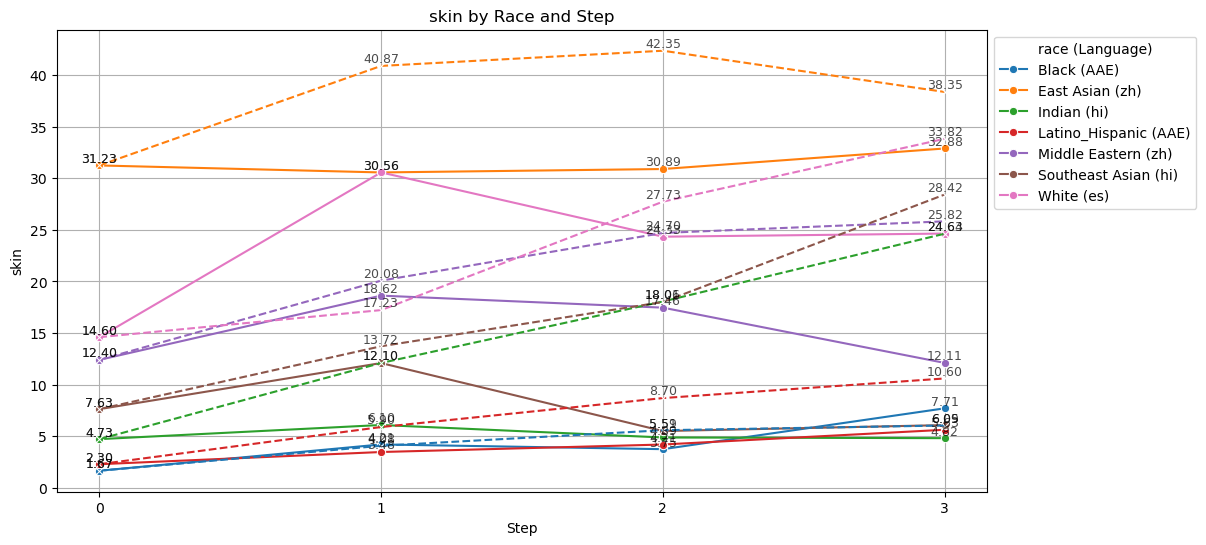

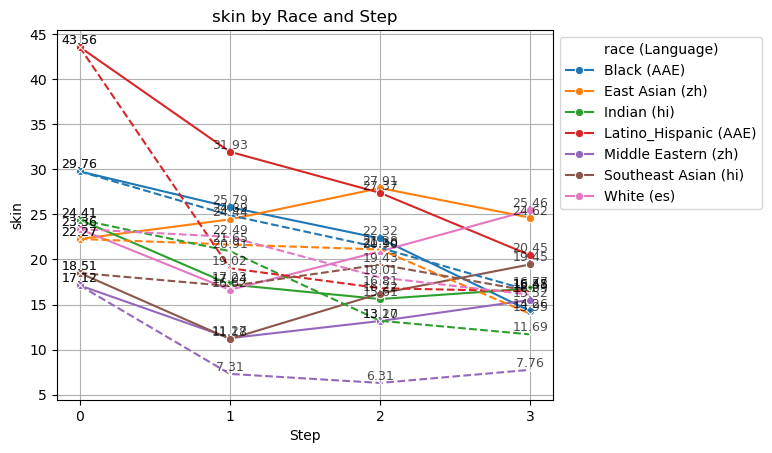

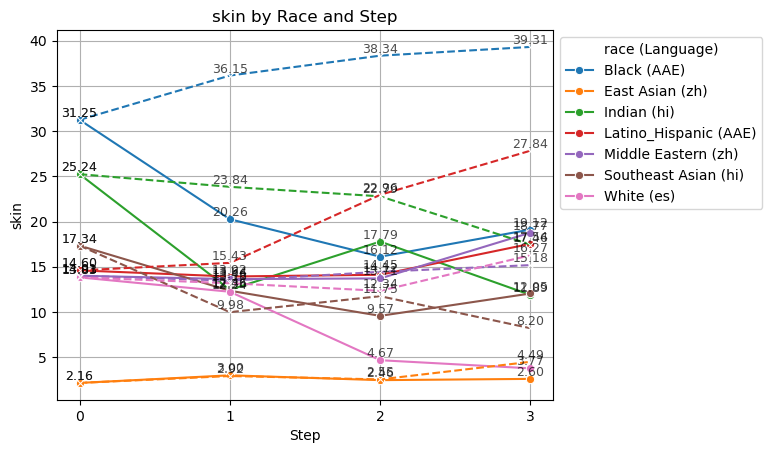

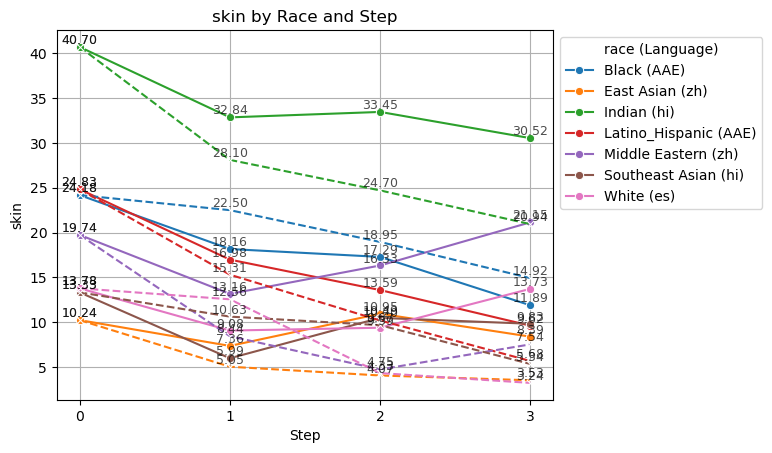

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
'''
    OA/SD
'''
# 读取第一个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data_1 = pd.read_csv(file_path_1)

# 读取第二个数据文件
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data_2 = pd.read_csv(file_path_2)
skin=['Skin_Status_health', 'Skin_Status_stain', 'Skin_Status_dark_circle', 'Skin_Status_acne']
# 描述性统计，按种族和递进步骤分类
description_1 = data_1.groupby(['race', 'Step'])[['Skin_Status_health', 'Skin_Status_stain', 'Skin_Status_dark_circle', 'Skin_Status_acne']].describe()
description_2 = data_2.groupby(['race', 'Step'])[['Skin_Status_health', 'Skin_Status_stain', 'Skin_Status_dark_circle', 'Skin_Status_acne']].describe()
print(description_1)
print(description_2)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores_1 = data_1.groupby(['Step', 'race']).agg({
    'Skin_Status_health': 'mean',
    'Skin_Status_stain': 'mean',
    'Skin_Status_dark_circle': 'mean',
    'Skin_Status_acne': 'mean'
}).reset_index()

mean_scores_2 = data_2.groupby(['Step', 'race']).agg({
    'Skin_Status_health': 'mean',
    'Skin_Status_stain': 'mean',
    'Skin_Status_dark_circle': 'mean',
    'Skin_Status_acne': 'mean'
}).reset_index()

# 创建种族和语言的对应关系
race_language_mapping = {
    'Middle Eastern': 'ar',
    'White': 'SAE',
    'Black': 'AAE',
    'East Asian': 'zh',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es'
}

# 添加语言列
mean_scores_1['Language'] = mean_scores_1['race'].map(race_language_mapping)
mean_scores_2['Language'] = mean_scores_2['race'].map(race_language_mapping)

# 绘图
plt.figure(figsize=(12, 6))
for skin in skin:
# 绘制第一个数据集
    sns.lineplot(data=mean_scores_1, x='Step', y=skin, hue='race', marker='o', linestyle='-', palette='tab10')

# 绘制第二个数据集
    sns.lineplot(data=mean_scores_2, x='Step', y=skin, hue='race', marker='x', linestyle='--', palette='tab10', legend=False)

# 添加每个点的数值标签，稍微调整位置
    for i in range(len(mean_scores_1)):
        plt.text(mean_scores_1['Step'][i], mean_scores_1[skin][i] + 0.02,
                f"{mean_scores_1[skin][i]:.2f}", 
                fontsize=9, ha='center', va='bottom', alpha=0.7)

    for i in range(len(mean_scores_2)):
        plt.text(mean_scores_2['Step'][i], mean_scores_2[skin][i] + 0.02,
                f"{mean_scores_2[skin][i]:.2f}", 
                fontsize=9, ha='center', va='bottom', alpha=0.7)

    # 设置图例格式为“种族（语言）”，并将图例移到右侧
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, [f"{labels[i]} ({mean_scores_1['Language'][i]})" for i in range(len(labels)//2)] +
                        [f"{labels[i]} ({mean_scores_2['Language'][i - len(labels)//2]})" for i in range(len(labels)//2, len(labels))], 
            title='race (Language)', loc='upper left', bbox_to_anchor=(1, 1))

    plt.title('skin by Race and Step')
    plt.xlabel('Step')
    plt.ylabel('skin')
    plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
    plt.grid()
    plt.show()

In [4]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'
file_path1 = r'd:\Users\AAA\Desktop\face++\StabB.csv'
df = pd.read_csv(file_path)
df1 = pd.read_csv(file_path1)
jiaocha="+ Language_ar * Step + Language_zh * Step + Language_es * Step + Language_id * Step + Language_hi * Step+ Language_AAE * Step + Gender * Step"
# 对Skin_Status_health进行混合效应模型分析
model_health = mixedlm("Skin_Status_health ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step", 
                      df, 
                      groups=df["Group"])
model_stain = mixedlm("Skin_Status_stain ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step", 
                      df, 
                      groups=df["Group"])
model_darkcircle = mixedlm("Skin_Status_dark_circle ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step", 
                      df, 
                      groups=df["Group"])
model_acne = mixedlm("Skin_Status_acne ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step", 
                      df, 
                      groups=df["Group"])


model_health1= mixedlm("Skin_Status_health ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step", 
                      df1, 
                      groups=df1["Group"])
model_stain1 = mixedlm("Skin_Status_stain ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step", 
                      df1, 
                      groups=df1["Group"])
model_darkcircle1 = mixedlm("Skin_Status_dark_circle ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender + Step", 
                      df1, 
                      groups=df1["Group"])
model_acne1 = mixedlm("Skin_Status_acne ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Gender + Step", 
                      df1, 
                      groups=df1["Group"])
# 拟合模型
result_health = model_health.fit()
result_stain = model_stain.fit()
result_darkcircle = model_darkcircle.fit()
result_acne = model_acne.fit()
result_health1 = model_health.fit()
result_stain1 = model_stain.fit()
result_darkcircle1 = model_darkcircle.fit()
result_acne1 = model_acne.fit()
# 打印结果
print("OpenArt")
print("健康",result_health.summary())
print("色斑",result_stain.summary())
print("黑眼圈",result_darkcircle.summary())
print("青春痘",result_acne.summary())
print("\n","Stablediffusion")
print("健康",result_health1.summary())
print("色斑",result_stain1.summary())
print("黑眼圈",result_darkcircle1.summary())
print("青春痘",result_acne1.summary())

OpenArt
健康              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Skin_Status_health
No. Observations: 1540    Method:             REML              
No. Groups:       70      Scale:              116.2596          
Min. group size:  22      Log-Likelihood:     -5964.6636        
Max. group size:  22      Converged:          Yes               
Mean group size:  22.0                                          
-----------------------------------------------------------------
                 Coef.   Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------
Intercept        15.039     1.984   7.579  0.000   11.150  18.929
Language_ar      -2.643     1.003  -2.636  0.008   -4.609  -0.678
Language_zh      -4.827     0.999  -4.831  0.000   -6.785  -2.869
Language_es      -3.099     0.997  -3.109  0.002   -5.053  -1.146
Language_id      -5.334     1.002  -5.322  0.000   -7.298  -3.369
Language_hi      -8.

In [2]:
import pandas as pd

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'
file_path1 = r'd:\Users\AAA\Desktop\face++\StabB.csv'
df = pd.read_csv(file_path)
df1 = pd.read_csv(file_path)
# 选择肤质相关列进行描述性统计分析
skin_status_columns = ['Skin_Status_health', 'Skin_Status_stain', 'Skin_Status_dark_circle', 'Skin_Status_acne']

# 对这些列进行描述性统计
description = df[skin_status_columns].describe()
description1 = df1[skin_status_columns].describe()
# 打印描述性统计分析结果
print("Openart\n",description)
print("Stablediffusion\n",description1)

Openart
        Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
count         1540.000000        1540.000000              1540.000000   
mean            12.437241          19.626562                12.263642   
std             18.104956          22.030389                19.808855   
min              0.081000           0.143000                 0.123000   
25%              1.663000           4.048250                 2.343000   
50%              4.347000          10.620000                 4.525000   
75%             13.634750          27.131250                10.665000   
max             92.169000          98.926000                99.794000   

       Skin_Status_acne  
count       1540.000000  
mean          15.643829  
std           22.443622  
min            0.113000  
25%            2.334000  
50%            5.933500  
75%           17.187750  
max           99.941000  
Stablediffusion
        Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
count    

d:\Anaconda3\envs\pytorch\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


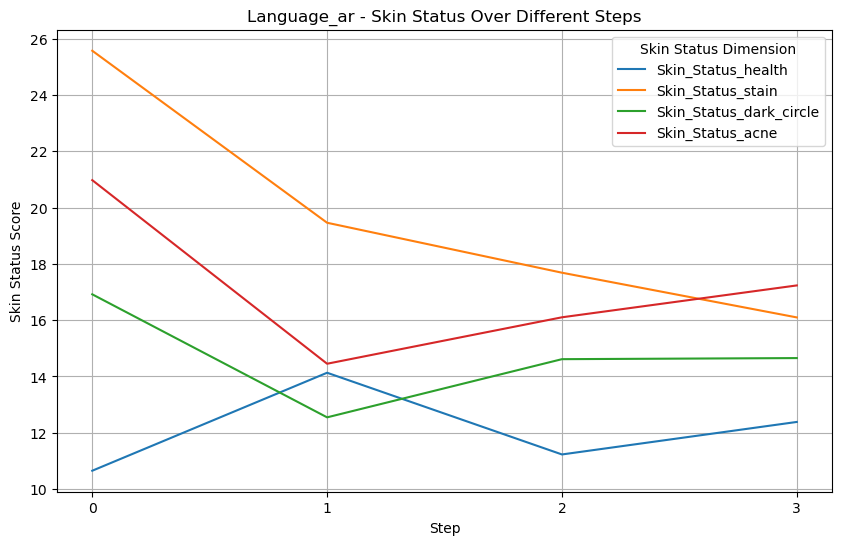

Language_ar    Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
0           10.651100          25.569586                16.917186   
1           14.131329          19.459000                12.546957   
2           11.229029          17.684629                14.613557   
3           12.383643          16.096414                14.652214   

   Skin_Status_acne  
0         20.972700  
1         14.451171  
2         16.100829  
3         17.232957  


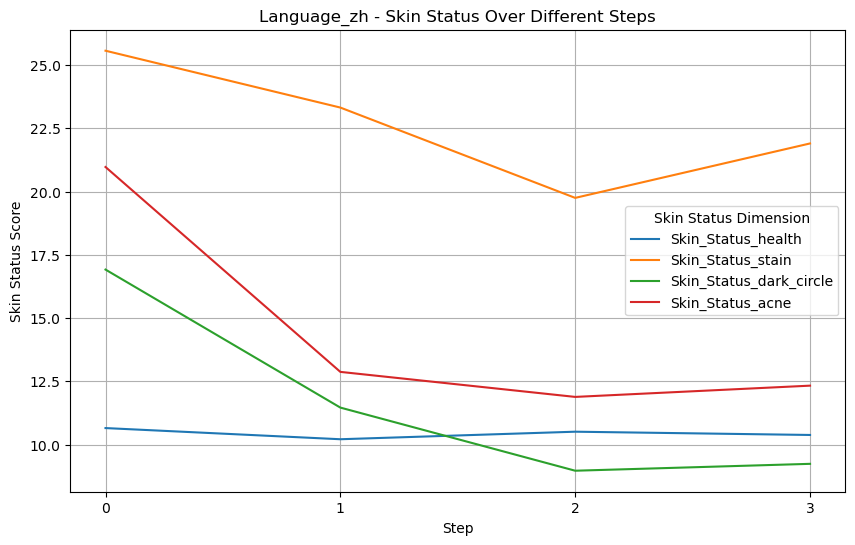

Language_zh    Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
0           10.651100          25.569586                16.917186   
1           10.209529          23.322229                11.460700   
2           10.507586          19.751400                 8.964900   
3           10.378514          21.903771                 9.237114   

   Skin_Status_acne  
0         20.972700  
1         12.872429  
2         11.883071  
3         12.328143  


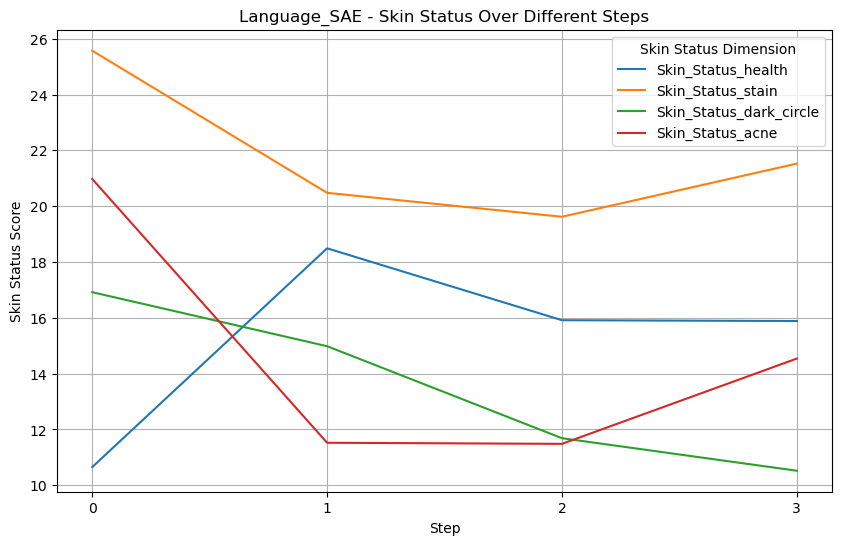

Language_SAE    Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
0           10.651100          25.569586                16.917186   
1           18.488857          20.477600                14.981886   
2           15.913257          19.619429                11.685157   
3           15.883443          21.524300                10.520000   

   Skin_Status_acne  
0         20.972700  
1         11.521843  
2         11.482957  
3         14.538529  


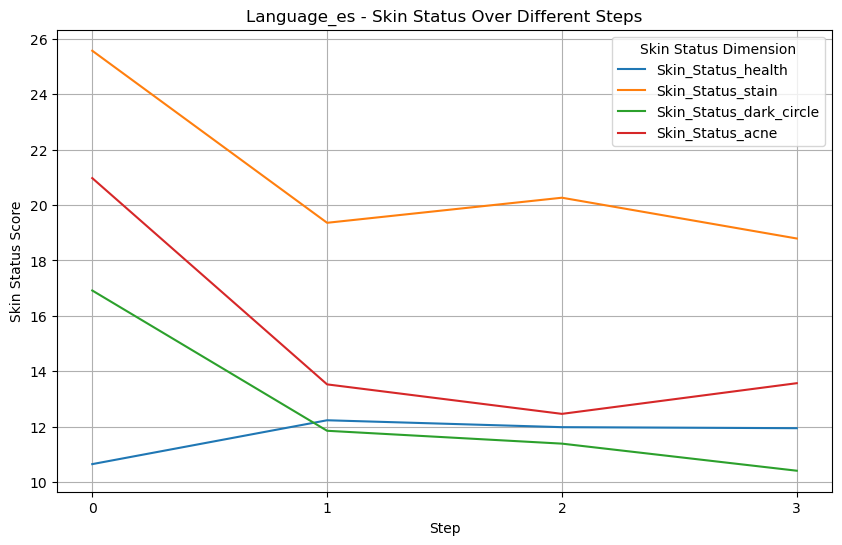

Language_es    Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
0           10.651100          25.569586                16.917186   
1           12.233886          19.360029                11.854514   
2           11.984614          20.264871                11.390386   
3           11.947857          18.793029                10.413014   

   Skin_Status_acne  
0         20.972700  
1         13.528871  
2         12.464614  
3         13.571786  


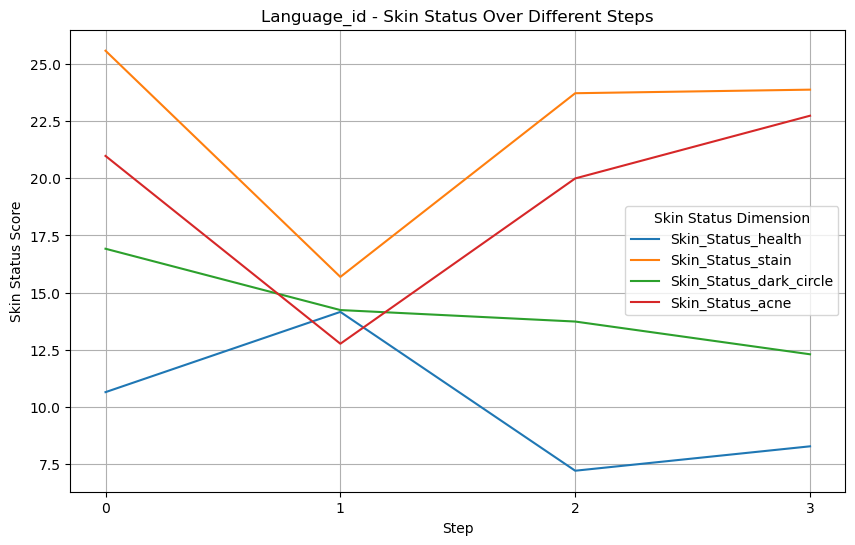

Language_id    Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
0           10.651100          25.569586                16.917186   
1           14.157543          15.686343                14.238043   
2            7.217714          23.712500                13.736000   
3            8.284071          23.868429                12.305457   

   Skin_Status_acne  
0         20.972700  
1         12.766086  
2         19.989514  
3         22.730043  


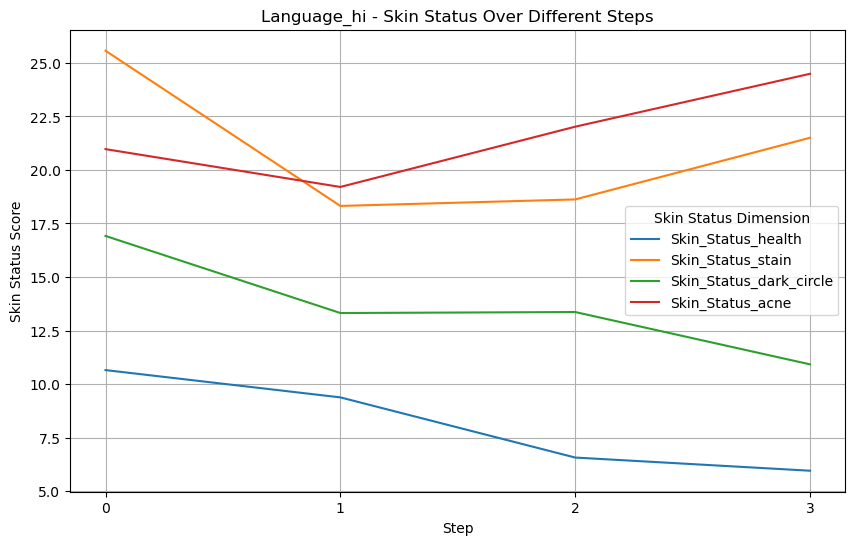

Language_hi    Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
0           10.651100          25.569586                16.917186   
1            9.376043          18.319214                13.316486   
2            6.565529          18.623143                13.363143   
3            5.950200          21.503643                10.918814   

   Skin_Status_acne  
0         20.972700  
1         19.205657  
2         22.020757  
3         24.492257  


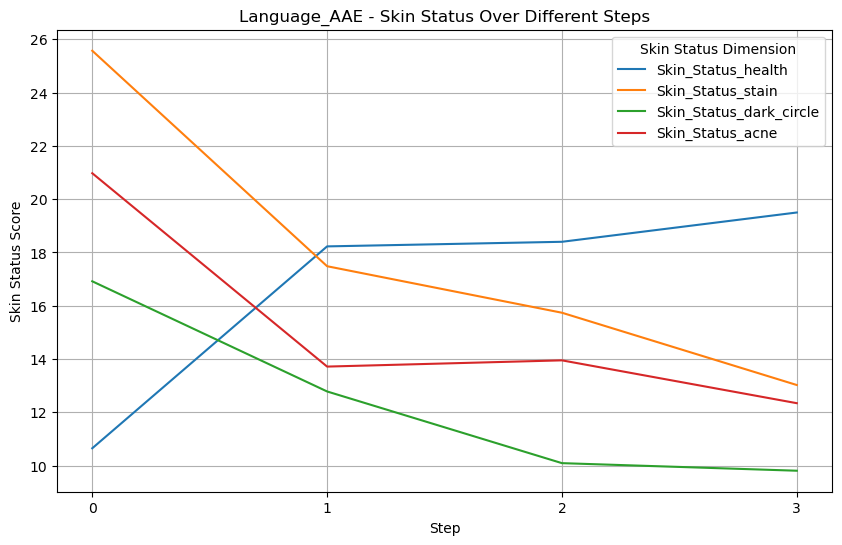

Language_AAE    Skin_Status_health  Skin_Status_stain  Skin_Status_dark_circle  \
0           10.651100          25.569586                16.917186   
1           18.226986          17.482800                12.782957   
2           18.399643          15.737157                10.092900   
3           19.498929          13.024843                 9.808729   

   Skin_Status_acne  
0         20.972700  
1         13.716557  
2         13.950557  
3         12.342900  


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'
df = pd.read_csv(file_path)

# 定义皮肤维度和语言编码
skin_status_columns = ['Skin_Status_health', 'Skin_Status_stain', 'Skin_Status_dark_circle', 'Skin_Status_acne']
languages = ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi','Language_AAE']

# 创建空的DataFrame来存储结果
results = {}

# 循环每个语言，分别计算每个递进层次的皮肤维度平均值
for lang in languages:
    lang_data = []
    for step in range(4):  # 遍历0, 1, 2, 3步
        # 过滤出该语言且递进层次为step的数据
        if step == 0:
            # 递进层次为0的图像，所有语言共享相同的原图
            filtered_data = df[df['Step'] == 0]
        else:
            # 递进层次不为0时，只筛选特定语言的数据
            filtered_data = df[(df[lang] == 1) & (df['Step'] == step)]
        
        # 计算4个皮肤维度的平均值
        mean_values = filtered_data[skin_status_columns].mean()
        lang_data.append(mean_values)
    
    # 将结果加入字典
    results[lang] = pd.DataFrame(lang_data, index=[0, 1, 2, 3], columns=skin_status_columns)

# 可视化结果 - 以英语为例
def plot_skin_status_for_language(language, result_df):
    plt.figure(figsize=(10, 6))
    
    for column in skin_status_columns:
        sns.lineplot(data=result_df, x=result_df.index, y=column, label=column)
    
    plt.title(f'{language} - Skin Status Over Different Steps')
    plt.xlabel('Step')
    plt.ylabel('Skin Status Score')
    plt.xticks([0, 1, 2, 3])
    plt.legend(title='Skin Status Dimension')
    plt.grid(True)
    plt.show()
for lang in languages:
# 调用绘图函数 - 以英语为例
    plot_skin_status_for_language(lang, results[lang])
    print(lang,results[lang])



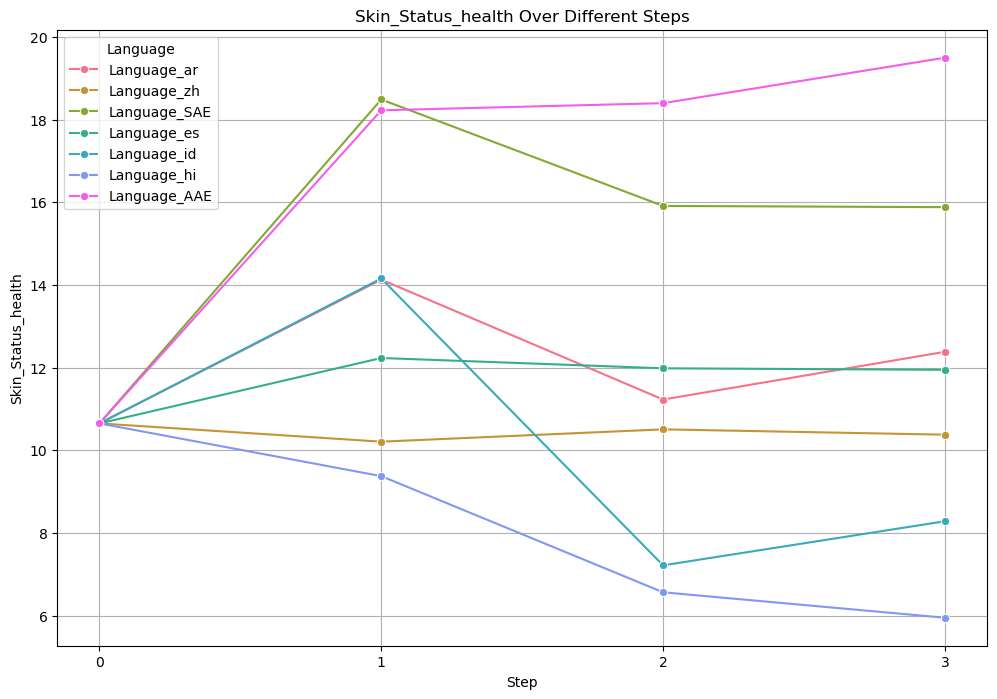

Average scores for Skin_Status_health:
   Step  Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0    0    10.651100    10.651100     10.651100    10.651100    10.651100   
1    1    14.131329    10.209529     18.488857    12.233886    14.157543   
2    2    11.229029    10.507586     15.913257    11.984614     7.217714   
3    3    12.383643    10.378514     15.883443    11.947857     8.284071   

   Language_hi  Language_AAE  
0    10.651100     10.651100  
1     9.376043     18.226986  
2     6.565529     18.399643  
3     5.950200     19.498929  


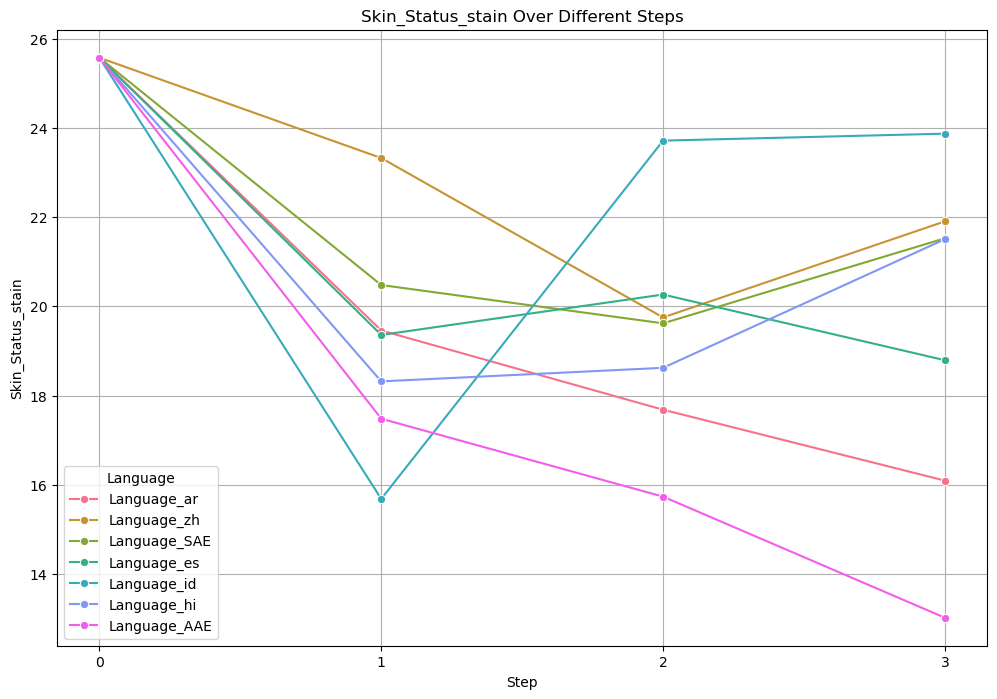

Average scores for Skin_Status_stain:
   Step  Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0    0    25.569586    25.569586     25.569586    25.569586    25.569586   
1    1    19.459000    23.322229     20.477600    19.360029    15.686343   
2    2    17.684629    19.751400     19.619429    20.264871    23.712500   
3    3    16.096414    21.903771     21.524300    18.793029    23.868429   

   Language_hi  Language_AAE  
0    25.569586     25.569586  
1    18.319214     17.482800  
2    18.623143     15.737157  
3    21.503643     13.024843  


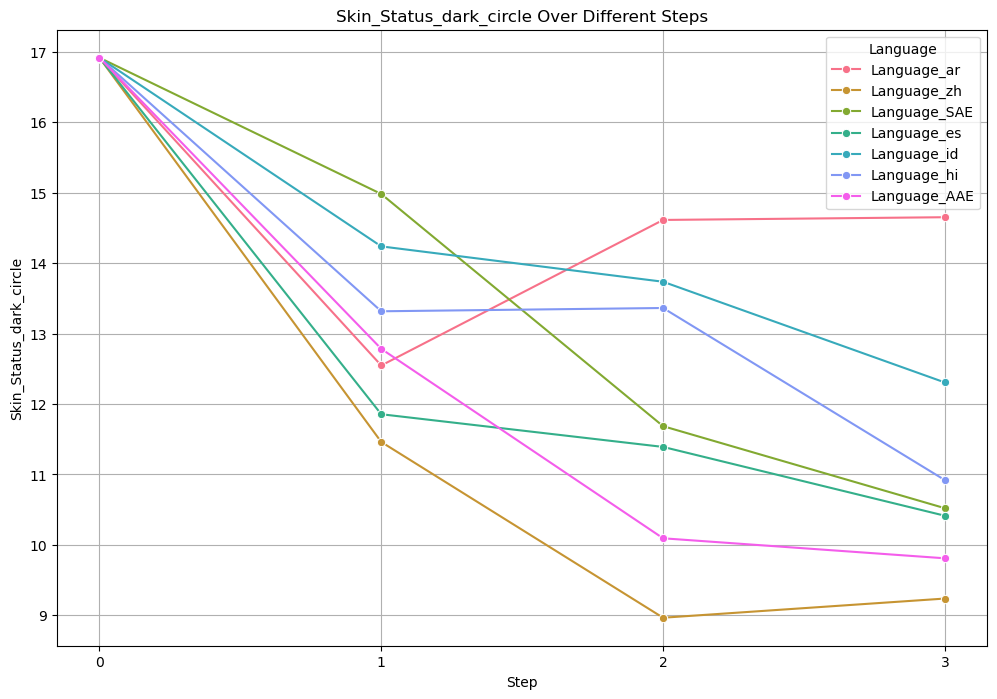

Average scores for Skin_Status_dark_circle:
   Step  Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0    0    16.917186    16.917186     16.917186    16.917186    16.917186   
1    1    12.546957    11.460700     14.981886    11.854514    14.238043   
2    2    14.613557     8.964900     11.685157    11.390386    13.736000   
3    3    14.652214     9.237114     10.520000    10.413014    12.305457   

   Language_hi  Language_AAE  
0    16.917186     16.917186  
1    13.316486     12.782957  
2    13.363143     10.092900  
3    10.918814      9.808729  


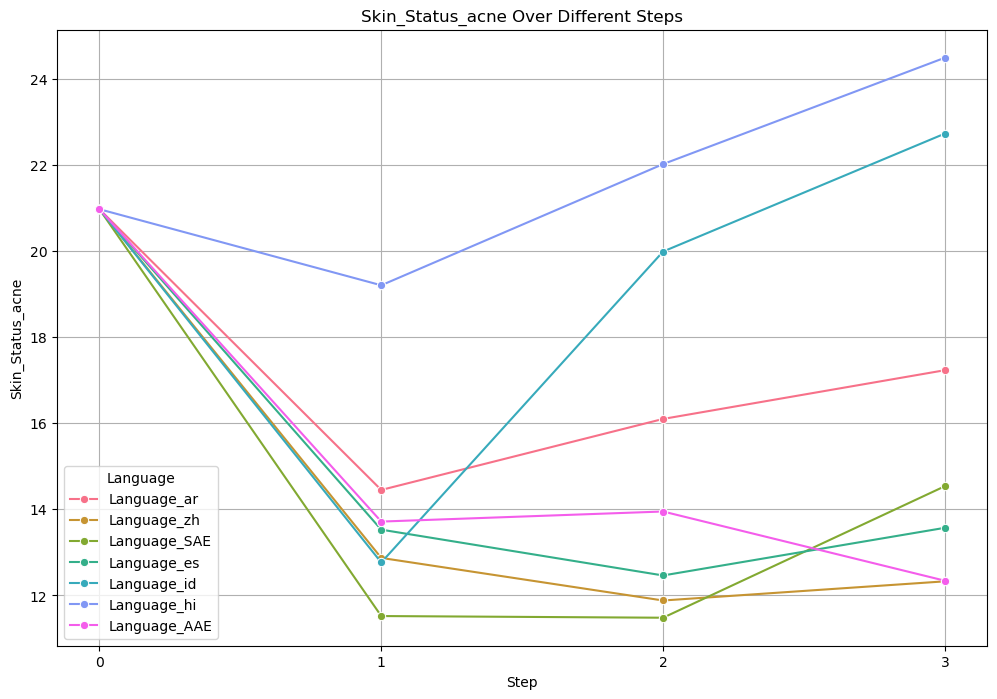

Average scores for Skin_Status_acne:
   Step  Language_ar  Language_zh  Language_SAE  Language_es  Language_id  \
0    0    20.972700    20.972700     20.972700    20.972700    20.972700   
1    1    14.451171    12.872429     11.521843    13.528871    12.766086   
2    2    16.100829    11.883071     11.482957    12.464614    19.989514   
3    3    17.232957    12.328143     14.538529    13.571786    22.730043   

   Language_hi  Language_AAE  
0    20.972700     20.972700  
1    19.205657     13.716557  
2    22.020757     13.950557  
3    24.492257     12.342900  


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'
df = pd.read_csv(file_path)

# 定义皮肤维度和语言编码
skin_status_columns = ['Skin_Status_health', 'Skin_Status_stain', 'Skin_Status_dark_circle', 'Skin_Status_acne']
languages = ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi', 'Language_AAE']

# 创建结果字典
results = {column: pd.DataFrame(columns=['Step'] + languages) for column in skin_status_columns}

# 循环每个皮肤维度
for skin_status_column in skin_status_columns:
    # 计算每个语言在不同步数下的均值
    for step in range(4):  # 遍历0, 1, 2, 3步
        row_data = {'Step': step}
        for lang in languages:
            if step == 0:
                filtered_data = df[df['Step'] == 0]
            else:
                filtered_data = df[(df[lang] == 1) & (df['Step'] == step)]
            
            # 计算均值
            mean_value = filtered_data[skin_status_column].mean()
            row_data[lang] = mean_value
        
        # 添加到结果DataFrame
        results[skin_status_column] = pd.concat([results[skin_status_column], pd.DataFrame([row_data])], ignore_index=True)

# 可视化结果 - 每个皮肤维度分别绘图
def plot_skin_status_over_languages(skin_status_column):
    plt.figure(figsize=(12, 8))
    
    # 转换为长格式
    long_format = results[skin_status_column].melt(id_vars=['Step'], var_name='Language', value_name='Score')
    
    # 绘制折线图
    palette = sns.color_palette("husl", len(languages))  # 使用调色板
    for lang in languages:
        lang_data = long_format[long_format['Language'] == lang]
        if not lang_data.empty:  # 确保有数据才绘制
            sns.lineplot(data=lang_data, x='Step', y='Score', label=lang, marker='o', color=palette[languages.index(lang)])
    
    plt.title(f'{skin_status_column} Over Different Steps')
    plt.xlabel('Step')
    plt.ylabel(skin_status_column)
    plt.xticks([0, 1, 2, 3])
    plt.legend(title='Language')
    plt.grid(True)
    plt.show()
    
    # 打印表格
    print(f'Average scores for {skin_status_column}:\n', results[skin_status_column])

# 绘制每个皮肤维度的图，并输出表格
for column in skin_status_columns:
    plot_skin_status_over_languages(column)


In [1]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''旧版本'''
# 读取数据
file_path = r'd:\Users\AAA\Desktop\face++\OpenA.csv'
df = pd.read_csv(file_path)

# 对Skin_Status_health进行混合效应模型分析
model_health = mixedlm("Skin_Status_health ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                      df, 
                      groups=df["Group"])
model_health2 = mixedlm("Skin_Status_health ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step + Language_al * Step + Language_cn * Step + Language_sp * Step + Language_yn * Step + Language_yd * Step + Gender * Step", 
                      df, 
                      groups=df["Group"])
model_stain = mixedlm("Skin_Status_stain ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step + Language_al * Step + Language_cn * Step + Language_sp * Step + Language_yn * Step + Language_yd * Step + Gender * Step", 
                      df, 
                      groups=df["Group"])
model_darkcircle = mixedlm("Skin_Status_dark_circle ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step + Language_al * Step + Language_cn * Step + Language_sp * Step + Language_yn * Step + Language_yd * Step + Gender * Step", 
                      df, 
                      groups=df["Group"])
model_acne = mixedlm("Skin_Status_acne ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step + Language_al * Step + Language_cn * Step + Language_sp * Step + Language_yn * Step + Language_yd * Step + Gender * Step", 
                      df, 
                      groups=df["Group"])

# 拟合模型
result_health = model_health.fit()
result_health2 = model_health2.fit()
result_stain = model_stain.fit()
result_darkcircle = model_darkcircle.fit()
result_acne = model_acne.fit()
# 打印结果
print("健康",result_health.summary())
print("健康（有交互项）",result_health2.summary())
print("色斑",result_stain.summary())
print("黑眼圈",result_darkcircle.summary())
print("青春痘",result_acne.summary())

d:\Anaconda3\envs\pytorch\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


健康              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Skin_Status_health
No. Observations: 1330    Method:             REML              
No. Groups:       70      Scale:              106.7330          
Min. group size:  19      Log-Likelihood:     -5106.7941        
Max. group size:  19      Converged:          Yes               
Mean group size:  19.0                                          
-----------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept         15.690     1.921   8.167  0.000  11.924  19.455
Language_al       -2.500     0.963  -2.595  0.009  -4.388  -0.612
Language_cn       -4.716     0.959  -4.916  0.000  -6.596  -2.836
Language_sp       -3.025     0.957  -3.162  0.002  -4.901  -1.150
Language_yn       -5.195     0.963  -5.397  0.000  -7.082  -3.308
Language_yd       -7.785    